# Exercise 2

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## part 1

In [213]:
np.random.seed(42)  # For reproducibility
p = 0.3
sample = 10000
random_numbers = np.random.geometric(p, size=sample)

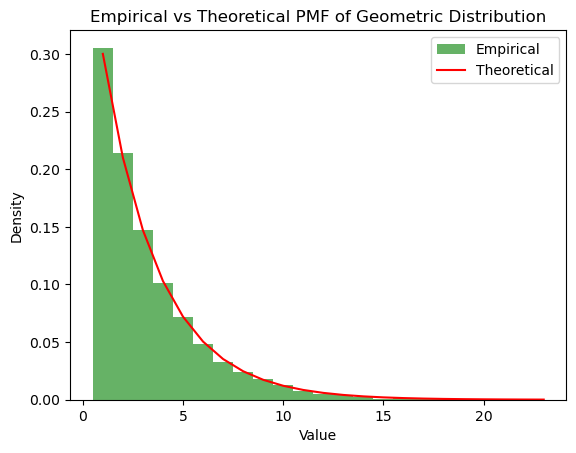

In [214]:
n, counts= np.unique(random_numbers, return_counts=True  )
theoretical = (1-p)**(n-1)*p

plt.hist(random_numbers, bins=np.arange(1, np.max(random_numbers)+1)-0.5, density=True, alpha=0.6, color='g', label='Empirical')
plt.plot(n, theoretical, 'r-', label='Theoretical')
plt.title("Empirical vs Theoretical PMF of Geometric Distribution")
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

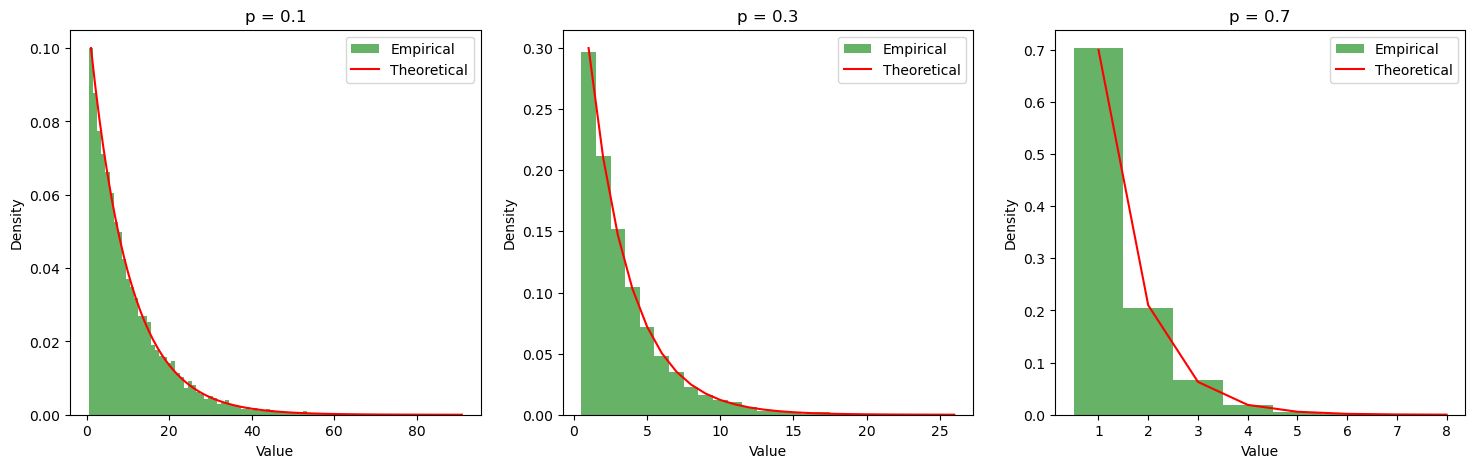

In [215]:
# make a subgifue with three plots of histograms and theoreitcal given three p values: 0.1, 0.3, 0.5
p_values = [0.1, 0.3, 0.7]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, p in enumerate(p_values):    
    random_numbers = np.random.geometric(p, size=sample)
    n, counts= np.unique(random_numbers, return_counts=True  )
    theoretical = (1-p)**(n-1)*p
    
    axes[i].hist(random_numbers, bins=np.arange(1, np.max(random_numbers)+1)-0.5, density=True, alpha=0.6, color='g', label='Empirical')
    axes[i].plot(n, theoretical, 'r-', label='Theoretical')
    axes[i].set_title(f"p = {p}")
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.show()

## part 2

In [216]:
#direct method
x = np.array([1, 2, 3, 4, 5,6 ])
p = np.array([7/48, 5/48, 1/8,1/16, 1/4,5/16])
np.random.seed(42)  # For reproducibility

def direct_method(x, p, size=10000):
    U = np.random.uniform(0, 1, size=10000)
    F = np.cumsum(p)
    X_direct = []
    for u in U:
        if 0 < u <= F[0]:
            X_direct.append(x[0])
        else:
            for i in range(1, len(x)):
                if F[i-1] < u <= F[i]:
                    X_direct.append(x[i])
                    break
    return X_direct

X_direct = direct_method(x, p)

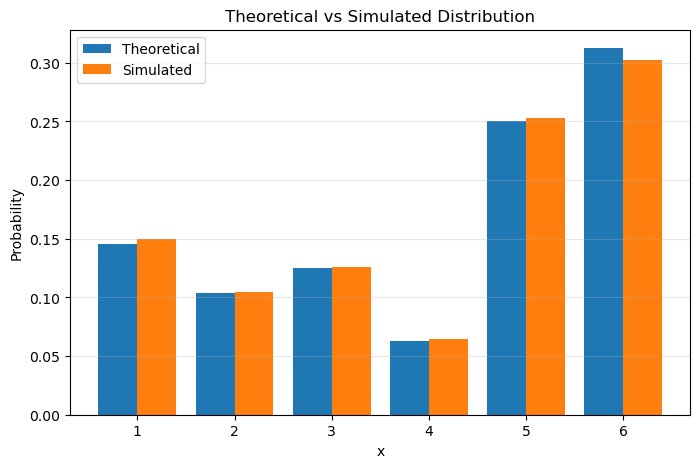

In [217]:
freq = []

for value in x:
    freq.append(X_direct.count(value) / len(X_direct))

# plot
width = 0.4

plt.figure(figsize=(8,5))
plt.bar(x - width/2, p, width, label='Theoretical')
plt.bar(x + width/2, freq, width, label='Simulated')

plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Theoretical vs Simulated Distribution')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [218]:
# rejection method:
def rejection_method(size, p, x):
    c = np.max(p) + 0.1
    k = len(x)
    X = []
    
    while len(X) < size:
        U1 = np.random.rand()
        U2 = np.random.rand()
        
        I = int(np.floor(k * U1))
        if U2 <= p[I] / c:
            X.append(I)
    
    return X

X_rejection = rejection_method(10000, p, x)

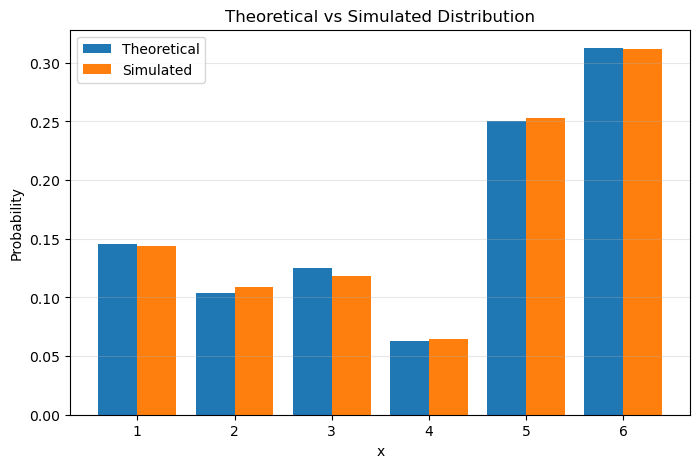

In [219]:
freq = []

for i, value in enumerate(x):
    freq.append(X_rejection.count(i) / len(X_rejection))

# plot
width = 0.4

plt.figure(figsize=(8,5))
plt.bar(x - width/2, p, width, label='Theoretical')
plt.bar(x + width/2, freq, width, label='Simulated')

plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Theoretical vs Simulated Distribution')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

In [220]:
# alias method:
def alias_table(p, x, epsilon=1e-10):
    k = len(x)
    L = np.arange(k)
    F = k * p.copy().astype(float)

    G = []
    S = []

    for i in range(k):
        if F[i] < 1:
            S.append(i)
        else:
            G.append(i)

    while len(S) > 0 and len(G) > 0:
        j = S.pop(0)      
        i = G[0]        

        L[j] = i
        F[i] = F[i] - (1 - F[j])

        if F[i] < 1 - epsilon:
            G.pop(0)
            S.append(i)

    return L, F, k

def alias_method(F, L, x, k, size=10000):
    X = []

    while len(X) < size:
        U1 = np.random.rand()
        U2 = np.random.rand()

        I = int(np.floor(k * U1))

        if U2 < F[I]:
            X.append(x[I])
        else:
            X.append(x[L[I]])

    return X

L, F, k = alias_table(p, x)
X_alias = alias_method(F, L, x, k)


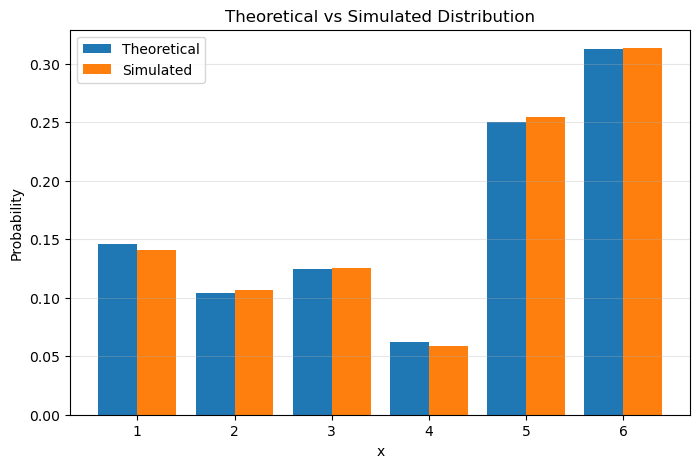

In [221]:
freq = []

for i, value in enumerate(x):
    freq.append(X_alias.count(value) / len(X_alias))

# plot
width = 0.4

plt.figure(figsize=(8,5))
plt.bar(x - width/2, p, width, label='Theoretical')
plt.bar(x + width/2, freq, width, label='Simulated')

plt.xlabel('x')
plt.ylabel('Probability')
plt.title('Theoretical vs Simulated Distribution')
plt.xticks(x)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## part 3

In [222]:
#time
from time import perf_counter

t = perf_counter()
X_direct = direct_method(x, p)
t_direct = perf_counter() - t

t = perf_counter()
X_rejection = rejection_method(10000, p, x)
t_rejection = perf_counter() - t

t = perf_counter()
X_alias = alias_method(F, L, x, k)
t_alias = perf_counter() - t

print(f"Direct method time: {t_direct:.4f} seconds")
print(f"Rejection method time: {t_rejection:.4f} seconds")
print(f"Alias method time: {t_alias:.4f} seconds")

Direct method time: 0.0321 seconds
Rejection method time: 0.0586 seconds
Alias method time: 0.0214 seconds


In [223]:
#chi-squared test
expected = [p[i] * len(X_direct) for i in range(len(x))]

observed_direct = [X_direct.count(val) for val in x]
chi2_stat_direct, p_value_direct = stats.chisquare(observed_direct, f_exp=expected)
print(f"Direct - Chi-squared statistic: {chi2_stat_direct:.4f}, p-value: {p_value_direct:.4f}")
if p_value_direct < 0.05:
    print("Reject null hypothesis: The distribution does not match the theoretical distribution.")
else:    print("Fail to reject null hypothesis: The distribution matches the theoretical distribution.")

observed_rejection = [X_rejection.count(i) for i in range(len(x))]
chi2_stat_rejection, p_value_rejection = stats.chisquare(observed_rejection, f_exp=expected)
print(f"Rejection - Chi-squared statistic: {chi2_stat_rejection:.4f}, p-value: {p_value_rejection:.4f}")
if p_value_rejection < 0.05:
    print("Reject null hypothesis: The distribution does not match the theoretical distribution.")
else:    print("Fail to reject null hypothesis: The distribution matches the theoretical distribution.")

observed_alias = [X_alias.count(val) for val in x]
chi2_stat_alias, p_value_alias = stats.chisquare(observed_alias, f_exp=expected)
print(f"Alias - Chi-squared statistic: {chi2_stat_alias:.4f}, p-value: {p_value_alias:.4f}")
if p_value_alias < 0.05:
    print("Reject null hypothesis: The distribution does not match the theoretical distribution.")
else:    print("Fail to reject null hypothesis: The distribution matches the theoretical distribution.")

Direct - Chi-squared statistic: 8.8804, p-value: 0.1139
Fail to reject null hypothesis: The distribution matches the theoretical distribution.
Rejection - Chi-squared statistic: 2.4321, p-value: 0.7867
Fail to reject null hypothesis: The distribution matches the theoretical distribution.
Alias - Chi-squared statistic: 4.5185, p-value: 0.4774
Fail to reject null hypothesis: The distribution matches the theoretical distribution.


In [224]:
import sys

def get_memory(obj):
    if isinstance(obj, np.ndarray):
        return sys.getsizeof(obj) + obj.nbytes
    if isinstance(obj, list):
        return sys.getsizeof(obj) + sum(sys.getsizeof(i) for i in obj)
    return sys.getsizeof(obj)

direct_mem = get_memory(X_direct)
rejection_mem = get_memory(X_rejection)

alias_samples_mem = get_memory(X_alias)
alias_table_mem = get_memory(L) + get_memory(F) + get_memory(k)
alias_total_mem = alias_samples_mem + alias_table_mem

print(f"Direct method memory usage: {direct_mem} bytes")
print(f"Rejection method memory usage: {rejection_mem} bytes")
print(f"Alias method memory usage (samples only): {alias_samples_mem} bytes")
print(f"Alias table memory usage (L, F, k): {alias_table_mem} bytes")
print(f"Alias method total memory usage: {alias_total_mem} bytes")

Direct method memory usage: 405176 bytes
Rejection method memory usage: 365176 bytes
Alias method memory usage (samples only): 405176 bytes
Alias table memory usage (L, F, k): 444 bytes
Alias method total memory usage: 405620 bytes


In [116]:
#generate each test 100 times to test the time and performance to see if there is a significant difference between the methods.
import time
def time_method(method, *args, repetitions=100):
    times = []
    for _ in range(repetitions):
        start_time = time.perf_counter()
        method(*args)
        end_time = time.perf_counter()
        times.append(end_time - start_time)
    return np.mean(times), np.std(times)

direct_time, direct_std = time_method(direct_method, x, p)
rejection_time, rejection_std = time_method(rejection_method, 10000, p, x)
alias_time, alias_std = time_method(alias_method, F, L, x, k)


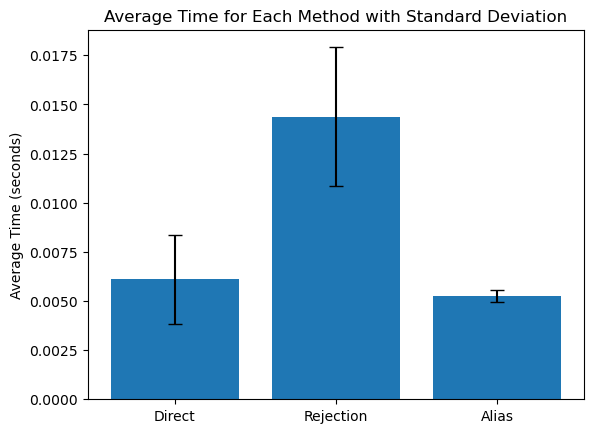

In [117]:
plt.bar(['Direct', 'Rejection', 'Alias'], [direct_time, rejection_time, alias_time], yerr=[direct_std, rejection_std, alias_std], capsize=5)
plt.ylabel('Average Time (seconds)')
plt.title('Average Time for Each Method with Standard Deviation')
plt.show()

In [118]:
def chi_squared_test(observed, expected):
    chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)
    return chi2_stat, p_value

repetitions = 100
alpha = 0.05
expected = p * sample  # expected counts for each category

chi2_results = {"direct": [], "rejection": [], "alias": []}
pval_results = {"direct": [], "rejection": [], "alias": []}

for _ in range(repetitions):
    # Direct
    X_direct = direct_method(x, p, size=sample)
    observed_direct = [X_direct.count(val) for val in x]
    chi2, pval = chi_squared_test(observed_direct, expected)
    chi2_results["direct"].append(chi2)
    pval_results["direct"].append(pval)

    # Rejection (returns indices 0..k-1)
    X_rejection = rejection_method(sample, p, x)
    observed_rejection = [X_rejection.count(i) for i in range(len(x))]
    chi2, pval = chi_squared_test(observed_rejection, expected)
    chi2_results["rejection"].append(chi2)
    pval_results["rejection"].append(pval)

    # Alias
    X_alias = alias_method(F, L, x, k, size=sample)
    observed_alias = [X_alias.count(val) for val in x]
    chi2, pval = chi_squared_test(observed_alias, expected)
    chi2_results["alias"].append(chi2)
    pval_results["alias"].append(pval)

for method in ["direct", "rejection", "alias"]:
    print(
        f"{method.capitalize()}: "
        f"mean chi2={np.mean(chi2_results[method]):.4f}, "
        f"mean p-value={np.mean(pval_results[method]):.4f}, "
        f"reject rate={(np.mean(np.array(pval_results[method]) < alpha) * 100):.1f}%"
    )



Direct: mean chi2=4.9862, mean p-value=0.5021, reject rate=4.0%
Rejection: mean chi2=6.0426, mean p-value=0.4263, reject rate=9.0%
Alias: mean chi2=4.4502, mean p-value=0.5449, reject rate=4.0%


# Exercise 3

## 1

### a

In [207]:
#exponential distribution
np.random.seed(42)  # For reproducibility 
Lambda = 1
U = np.random.uniform(0, 1, size=10000)
X_exp = -np.log(U) / Lambda

x_exp = np.linspace(0, max(X_exp), 10000)
theoretical_exp = Lambda * np.exp(-Lambda * x_exp)

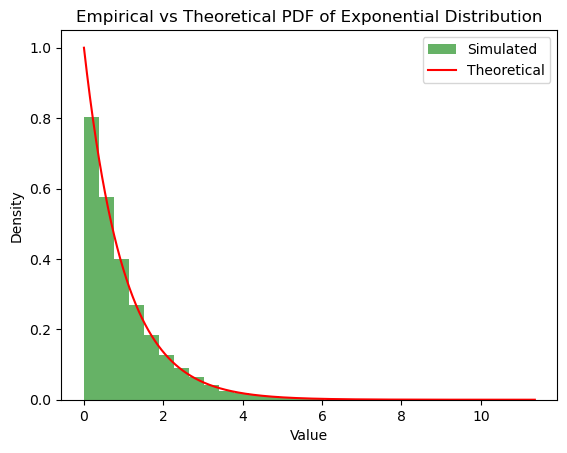

In [210]:
plt.hist(X_exp, bins=30, density=True, alpha=0.6, color='g', label='Simulated')
plt.plot(x_exp, theoretical_exp, 'r-', label='Theoretical')
plt.title("Empirical vs Theoretical PDF of Exponential Distribution")
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

### b

(array([1.04713978e-03, 0.00000000e+00, 1.39618637e-03, 5.58474548e-03,
        1.01223512e-02, 2.82727740e-02, 4.01403581e-02, 8.16769026e-02,
        1.24609633e-01, 1.87787067e-01, 2.69463969e-01, 3.11698607e-01,
        3.51489919e-01, 3.78715553e-01, 3.90234090e-01, 3.48697546e-01,
        2.93897231e-01, 2.40144056e-01, 1.57070967e-01, 1.23562494e-01,
        6.63188526e-02, 3.83951252e-02, 2.37351683e-02, 1.04713978e-02,
        3.83951252e-03, 1.04713978e-03, 6.98093185e-04, 0.00000000e+00,
        0.00000000e+00, 3.49046592e-04]),
 array([-3.97017524, -3.68368054, -3.39718583, -3.11069113, -2.82419643,
        -2.53770172, -2.25120702, -1.96471232, -1.67821761, -1.39172291,
        -1.10522821, -0.8187335 , -0.5322388 , -0.24574409,  0.04075061,
         0.32724531,  0.61374002,  0.90023472,  1.18672942,  1.47322413,
         1.75971883,  2.04621353,  2.33270824,  2.61920294,  2.90569764,
         3.19219235,  3.47868705,  3.76518175,  4.05167646,  4.33817116,
         4.62466

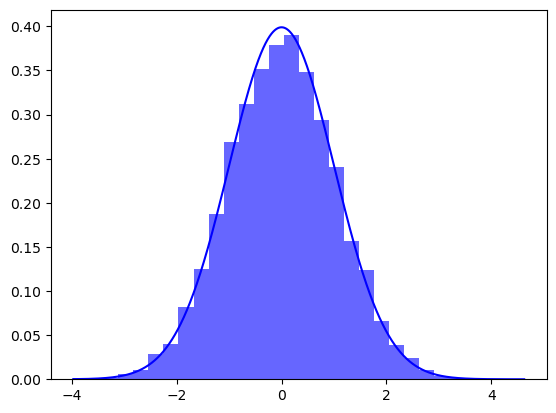

In [199]:
# box muller method
np.random.seed(42)  # For reproducibility
def norm_box(size=10000):
    U1 = np.random.rand(size)
    U2 = np.random.rand(size)
    Z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    Z2 = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)
    return Z1, Z2

X_norm, _ = norm_box(size=10000)

x_norm = np.linspace(min(X_norm), max(X_norm), 10000)
theoretical_norm = stats.norm.pdf(x_norm, loc=0, scale=1)
plt.plot(x_norm, theoretical_norm, 'b-', label='Theoretical Normal')

plt.hist(X_norm, bins=30, density=True, alpha=0.6, color='b', label='Box-Muller Z1')

### c

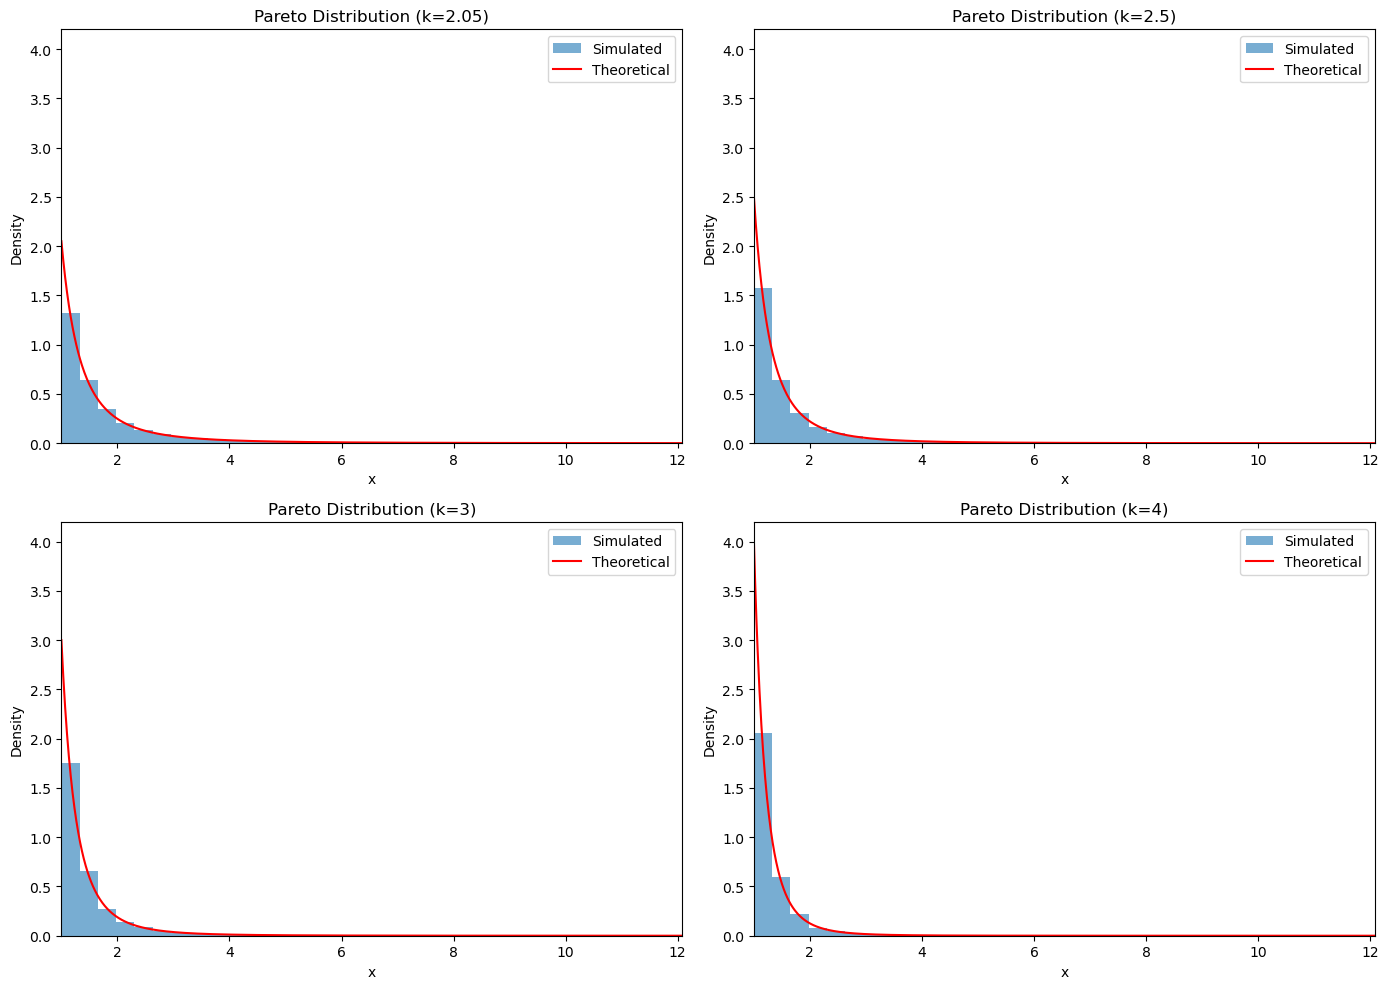

In [ ]:
#pareto distribution
np.random.seed(42)
beta = 1

k = [2.05, 2.5, 3, 4]
X_pareto_all = {}
for k_value in k:
    U = np.random.rand(10000)
    X_pareto = beta * (U ** (-1/k_value))
    X_pareto_all[k_value] = X_pareto

x_pareto = np.linspace(min(X_pareto_all[k[0]]), max(X_pareto_all[k[0]]), 10000)
theoretical_pareto = stats.pareto.pdf(x_pareto, b=k[0], scale=beta)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# common x-axis (same for all subplots)
x_max_common = max(np.percentile(X_pareto_all[kv], 99.5) for kv in k)
x_grid_common = np.linspace(beta, x_max_common, 1000)
bins_common = np.linspace(beta, x_max_common, 35)

# common y-axis (same for all subplots)
y_max_common = 0
for kv in k:
    y_theory = stats.pareto.pdf(x_grid_common, b=kv, scale=beta)
    y_hist, _ = np.histogram(X_pareto_all[kv], bins=bins_common, density=True)
    y_max_common = max(y_max_common, np.max(y_theory), np.max(y_hist))

for i, k_value in enumerate(k):
    X_pareto = X_pareto_all[k_value]
    theoretical_pareto = stats.pareto.pdf(x_grid_common, b=k_value, scale=beta)

    axes[i].hist(
        X_pareto,
        bins=bins_common,
        density=True,
        alpha=0.6,
        label='Simulated'
    )
    axes[i].plot(x_grid_common, theoretical_pareto, 'r-', label='Theoretical')
    axes[i].set_title(f'Pareto Distribution (k={k_value})')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('Density')
    axes[i].set_xlim(beta, x_max_common)
    axes[i].set_ylim(0, y_max_common * 1.05)
    axes[i].legend()

# hide any unused subplot
for j in range(len(k), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [185]:
# KS test summary table for exponential, normal, and pareto
alpha = 0.05
results = []

def decision_text(p_value, alpha=0.05):
    return "Reject H0" if p_value < alpha else "Fail to reject H0"

# Exponential
ks_stat_exp, ks_pval_exp = stats.kstest(X_exp, 'expon', args=(0, 1 / Lambda))
results.append(("Exponential", ks_stat_exp, ks_pval_exp, decision_text(ks_pval_exp, alpha)))

# Normal
ks_stat_norm, ks_pval_norm = stats.kstest(X_norm, 'norm', args=(0, 1))
results.append(("Normal", ks_stat_norm, ks_pval_norm, decision_text(ks_pval_norm, alpha)))

# Pareto (shape=k_value, loc=0, scale=beta)
for k_value in k:
    ks_stat_pareto, ks_pval_pareto = stats.kstest(
        X_pareto_all[k_value], 'pareto', args=(k_value, 0, beta)
    )
    results.append((f"Pareto (k={k_value})", ks_stat_pareto, ks_pval_pareto, decision_text(ks_pval_pareto, alpha)))

# Pretty print
print(f"{'Distribution':<20} {'KS statistic':>12} {'p-value':>12} {'Decision (alpha=0.05)':>26}")
print("-" * 74)
for name, stat, pval, dec in results:
    print(f"{name:<20} {stat:>12.4f} {pval:>12.4f} {dec:>26}")



Distribution         KS statistic      p-value      Decision (alpha=0.05)
--------------------------------------------------------------------------
Exponential                0.0119       0.1164          Fail to reject H0
Normal                     0.0084       0.4858          Fail to reject H0
Pareto (k=2.05)            0.0125       0.0859          Fail to reject H0
Pareto (k=2.5)             0.0097       0.3072          Fail to reject H0
Pareto (k=3)               0.0073       0.6606          Fail to reject H0
Pareto (k=4)               0.0061       0.8514          Fail to reject H0


## 2

In [188]:
# expected value
theory_mean = {}
for k_value in k:
    theory_mean[f"Pareto (k={k_value})"] = beta * k_value / (k_value - 1) if k_value > 1 else float('inf')

theory_variance = {}
for k_value in k:
    if k_value > 2:
        theory_variance[f"Pareto (k={k_value})"] = (beta**2 * k_value) / ((k_value - 1)**2 * (k_value - 2))
    else:
        theory_variance[f"Pareto (k={k_value})"] = float('inf')

mean_emperical = {}
var_emperical = {}
for k_value in k:
    mean_emperical[f"Pareto (k={k_value})"] = np.mean(X_pareto_all[k_value])
    var_emperical[f"Pareto (k={k_value})"] = np.var(X_pareto_all[k_value], ddof=1)


print("Expected Value Comparison:")
print(f"{'Distribution':<20} {'Theoretical Mean':>20} {'Empirical Mean':>20}")
print("-" * 60)
for k_value in k:
        dist_name = f"Pareto (k={k_value})"
        print(f"{dist_name:<20} {theory_mean[dist_name]:>20.4f} {mean_emperical[dist_name]:>20.4f}")

print("\nVariance Comparison:")
print(f"{'Distribution':<20} {'Theoretical Variance':>25} {'Empirical Variance':>25}")
print("-" * 70)
for k_value in k:
        dist_name = f"Pareto (k={k_value})"
        print(f"{dist_name:<20} {theory_variance[dist_name]:>25.4f} {var_emperical[dist_name]:>25.4f}")


Expected Value Comparison:
Distribution             Theoretical Mean       Empirical Mean
------------------------------------------------------------
Pareto (k=2.05)                    1.9524               1.9999
Pareto (k=2.5)                     1.6667               1.6516
Pareto (k=3)                       1.5000               1.4945
Pareto (k=4)                       1.3333               1.3374

Variance Comparison:
Distribution              Theoretical Variance        Empirical Variance
----------------------------------------------------------------------
Pareto (k=2.05)                        37.1882                   15.4829
Pareto (k=2.5)                          2.2222                    1.4193
Pareto (k=3)                            0.7500                    0.7156
Pareto (k=4)                            0.2222                    0.2568


## 3

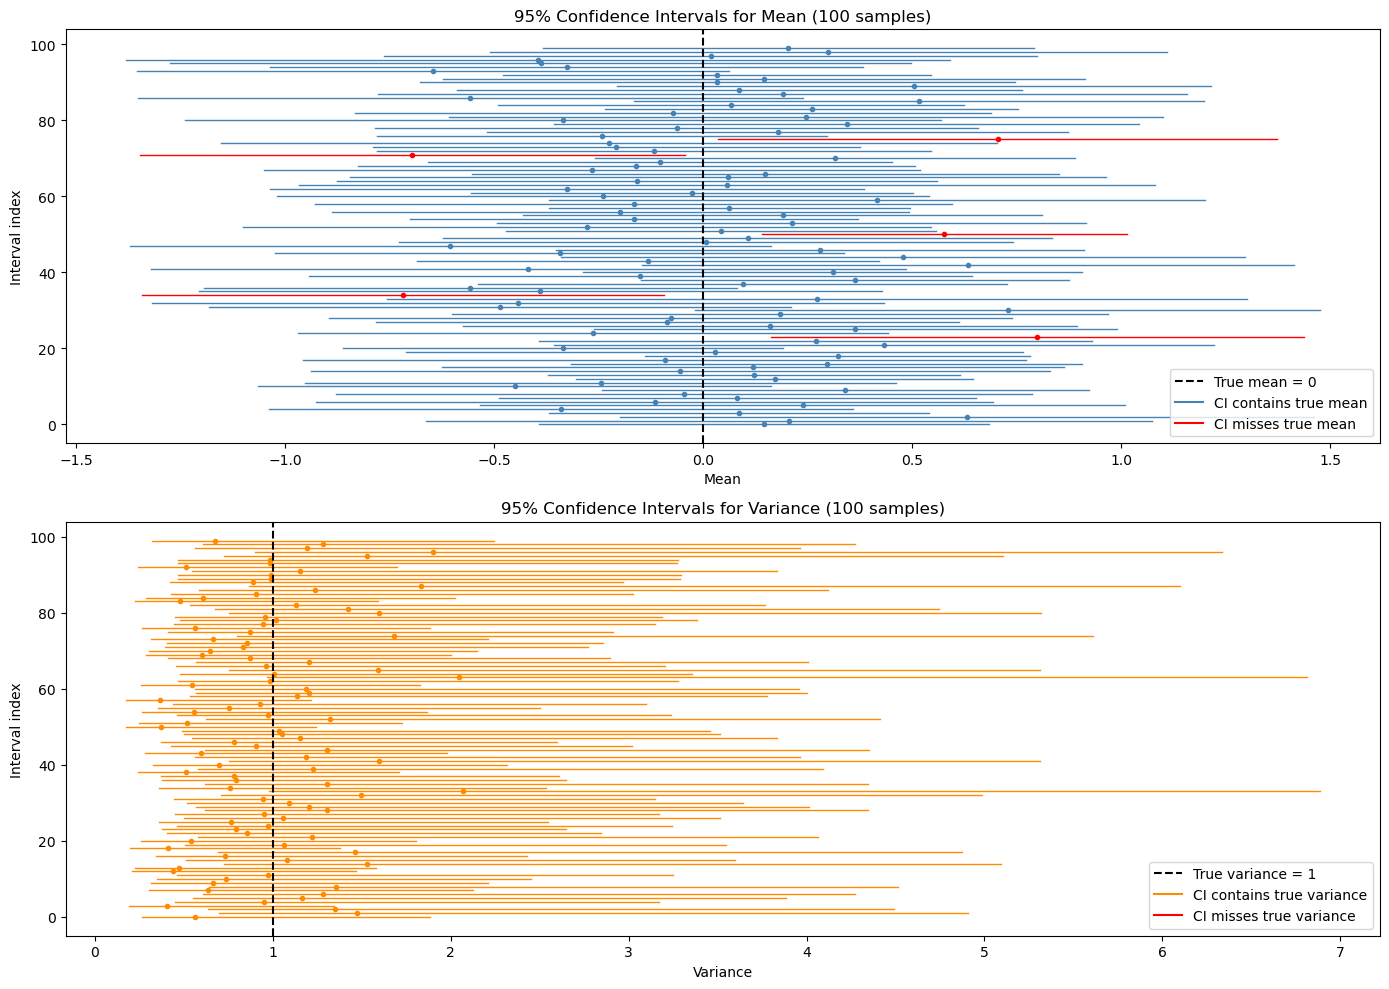

Mean CI misses true value: 5/100
Variance CI misses true value: 0/100


In [204]:
np.random.seed(42)

n_intervals = 100
n_samples = 10
true_mean = 0
true_var = 1

mean_ci_list = []
var_ci_list = []
means = []
variances = []

for i in range(n_intervals):
    X_norm, _ = norm_box(size=n_samples)
    sample_mean = np.mean(X_norm)
    sample_var = np.var(X_norm, ddof=1)
    means.append(sample_mean)
    variances.append(sample_var)

    mean_ci = stats.t.interval(0.95, df=n_samples-1, loc=sample_mean, scale=stats.sem(X_norm))
    mean_ci_list.append(mean_ci)

    chi2_low, chi2_high = stats.chi2.ppf([0.025, 0.975], df=n_samples-1)
    var_ci = ((n_samples - 1) * sample_var / chi2_high, (n_samples - 1) * sample_var / chi2_low)
    var_ci_list.append(var_ci)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
# --- Mean CI plot ---
for i, (ci, m) in enumerate(zip(mean_ci_list, means)):
    color = 'red' if ci[0] > true_mean or ci[1] < true_mean else 'steelblue'
    axes[0].plot([ci[0], ci[1]], [i, i], color=color, linewidth=1)
    axes[0].plot(m, i, 'o', color=color, markersize=3)
axes[0].axvline(true_mean, color='black', linestyle='--', label='True mean = 0')
axes[0].plot([], [], color='steelblue', label='CI contains true mean')
axes[0].plot([], [], color='red', label='CI misses true mean')
axes[0].set_title('95% Confidence Intervals for Mean (100 samples)')
axes[0].set_xlabel('Mean')
axes[0].set_ylabel('Interval index')
axes[0].legend()

# --- Variance CI plot ---
for i, (ci, v) in enumerate(zip(var_ci_list, variances)):
    color = 'red' if ci[0] > true_var or ci[1] < true_var else 'darkorange'
    axes[1].plot([ci[0], ci[1]], [i, i], color=color, linewidth=1)
    axes[1].plot(v, i, 'o', color=color, markersize=3)
axes[1].axvline(true_var, color='black', linestyle='--', label='True variance = 1')
axes[1].plot([], [], color='darkorange', label='CI contains true variance')
axes[1].plot([], [], color='red', label='CI misses true variance')
axes[1].set_title('95% Confidence Intervals for Variance (100 samples)')
axes[1].set_xlabel('Variance')
axes[1].set_ylabel('Interval index')
axes[1].legend()

plt.tight_layout()
plt.show()

mean_miss = sum(1 for ci in mean_ci_list if ci[0] > true_mean or ci[1] < true_mean)
var_miss = sum(1 for ci in var_ci_list if ci[0] > true_var or ci[1] < true_var)
print(f"Mean CI misses true value: {mean_miss}/100")
print(f"Variance CI misses true value: {var_miss}/100")

## 4

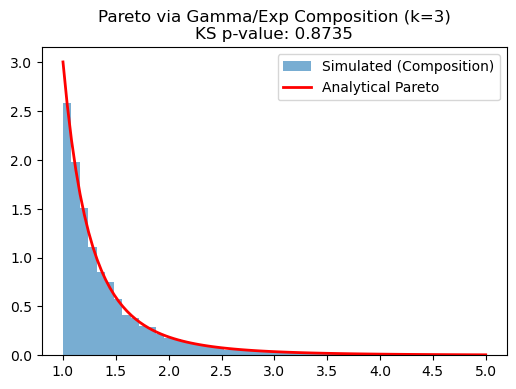

In [ ]:
#parato using composition method
np.random.seed(42)
N_comp = 10000
lambda_comb = 1.0
k_comp = 3 

#Generate Y ~ Gamma/Erlang(k=3, rate=lambda_comb) 
U1, U2, U3 = np.random.rand(3, N_comp)
Y = -(1.0 / lambda_comb) * np.log(U1 * U2 * U3)

# Generate X_cond ~ Exp(rate=Y)
U4 = np.random.rand(N_comp)
X_cond = -(1.0 / Y) * np.log(U4)

# Step 3: Shift to strictly obtain Pareto on [lambda_comb, infinity[
X_comp = X_cond + lambda_comb

# Verification: Compare Composition Pareto vs Analytical Pareto
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(X_comp, bins=50, range=(1, 5), density=True, alpha=0.6, label="Simulated (Composition)")

x_c = np.linspace(1, 5, 100)
ax.plot(x_c, stats.pareto.pdf(x_c, b=k_comp, scale=lambda_comb), 'r-', lw=2, label="Analytical Pareto")

ks_comp = stats.kstest(X_comp, lambda x: stats.pareto.cdf(x, b=k_comp, scale=lambda_comb))
ax.set_title(f"Pareto via Gamma/Exp Composition (k=3)\nKS p-value: {ks_comp.pvalue:.4f}")
ax.legend()
plt.show()